# LSTM Evaluation (HDFS)

### Импорты

In [1]:
import sys

from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import average_precision_score

cwd = Path.cwd().resolve()
if (cwd / "FastAPI").exists():
    CHECKPOINT_DIR = cwd
elif cwd.name == "notebooks" and (cwd.parent / "FastAPI").exists():
    CHECKPOINT_DIR = cwd.parent
else:
    CHECKPOINT_DIR = cwd / "Checkpoint_6"

sys.path.insert(0, str(CHECKPOINT_DIR / "FastAPI"))

from model.lstm_model import LSTMNextEventModel

from model.lstm_metrics import (
    block_confusion_from_ratio_map,
    predict_topk_miss,
    block_anomaly_ratio_map,
    sweep_thresholds,
)

plt.style.use("default")
CHECKPOINT_DIR

PosixPath('/Users/andrew/PycharmProjects/anomaly-detection-distributed-clouds/Checkpoint_6')

### Загрузка данных

In [2]:
DATA_PATH = CHECKPOINT_DIR / "data" / "preprocessed" / "seq_out" / "hdfs_sequence_data.npz"
MODEL_PATH = CHECKPOINT_DIR / "FastAPI" / "model" / "lstm_model.pt"
HISTORY_PATH = CHECKPOINT_DIR / "experiments" / "lstm_model.history.json"
LOG_PATH = CHECKPOINT_DIR / "data" / "HDFS.log"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Missing one-step LSTM dataset: {DATA_PATH}. "
        "Build it with scripts/prepare_hdfs_sequences.py before running this notebook."
    )
if not MODEL_PATH.exists():
    raise FileNotFoundError(MODEL_PATH)

print("DATA_PATH:", DATA_PATH)
print("MODEL_PATH:", MODEL_PATH)

DATA_PATH: /Users/andrew/PycharmProjects/anomaly-detection-distributed-clouds/Checkpoint_6/data/preprocessed/seq_out/hdfs_sequence_data.npz
MODEL_PATH: /Users/andrew/PycharmProjects/anomaly-detection-distributed-clouds/Checkpoint_6/FastAPI/model/lstm_model.pt


In [3]:
data = np.load(DATA_PATH, allow_pickle=True)
x_train = data["X_train"]
y_train = data["y_train"]
x_val = data["X_val"]
y_val = data["y_val"]
x_test = data["X_test"]
y_test = data["y_test"]
val_labels = data["val_labels"]
val_block_ids = data["val_block_ids"]
test_labels = data["test_labels"]
test_block_ids = data["test_block_ids"]

print("Train size:", x_train.shape[0])
print("Val size:", x_val.shape[0])
print("Test size:", x_test.shape[0])

Train size: 4242856
Val size: 579655
Test size: 645520


### Загрузка модели

In [4]:
ckpt = torch.load(MODEL_PATH, map_location="cpu")
config = ckpt.get("config", {})
vocab_size = int(ckpt["vocab_size"])

model = LSTMNextEventModel(
    vocab_size=vocab_size,
    embedding_dim=int(config.get("embedding_dim", 32)),
    hidden_size=int(config.get("hidden_size", 64)),
    num_layers=int(config.get("num_layers", 1)),
    dropout=float(config.get("dropout", 0.0)),
)
model.load_state_dict(ckpt["state_dict"])

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

config

{'embedding_dim': 32,
 'hidden_size': 64,
 'num_layers': 1,
 'dropout': 0.0,
 'top_k': 3,
 'anomaly_ratio_threshold': 0.09183673469387756,
 'device': 'cpu'}

### Оценка качества

In [5]:
top_k = int(config.get("top_k", 3))
default_thr = float(config.get("anomaly_ratio_threshold", 0.5))

# Считаем промахи по окнам
val_miss = predict_topk_miss(model, x_val, y_val, device, top_k)
test_miss = predict_topk_miss(model, x_test, y_test, device, top_k)

# Агрегируем промахи по окнам (для каждого block_id получаем anomaly_ratio)
val_ratio_map = block_anomaly_ratio_map(val_miss, val_block_ids)
test_ratio_map = block_anomaly_ratio_map(test_miss, test_block_ids)

# Достаем значения anomaly_ratio
val_ratios = np.array(list(val_ratio_map.values()), dtype=float)
test_ratios = np.array(list(test_ratio_map.values()), dtype=float)

# Метки для валидации и теста
test_label_map = {str(bid): int(lbl) for bid, lbl in zip(test_block_ids, test_labels)}
val_label_map = {str(bid): int(lbl) for bid, lbl in zip(val_block_ids, val_labels)}

In [6]:
def print_confusion_metrics(tp, fp, tn, fn):
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    fpr = fp / (fp + tn)
    f1 = (2 * precision * recall / (precision + recall))

    print("Confusion matrix (test):")
    print(f" TP: {tp}  FP: {fp}")
    print(f" FN: {fn}  TN: {tn}")
    print()
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1:        {f1:.3f}")
    print(f"FPR:       {fpr:.3f}")

tp, fp, tn, fn = block_confusion_from_ratio_map(test_ratio_map, test_label_map, default_thr)
print_confusion_metrics(tp, fp, tn, fn)

Confusion matrix (test):
 TP: 5536  FP: 1213
 FN: 1944  TN: 54610

Precision: 0.820
Recall:    0.740
F1:        0.778
FPR:       0.022


- Precision: 0.820 - большинство срабатываний действительно аномалии
- Recall: 0.740 - модель пропускает около 26% аномалий
- FPR: 0.022 - очень мало ложных тревог на норме
- F1: 0.778 - среднее качество с упором на точность


### Распределение anomaly_ratio по блокам

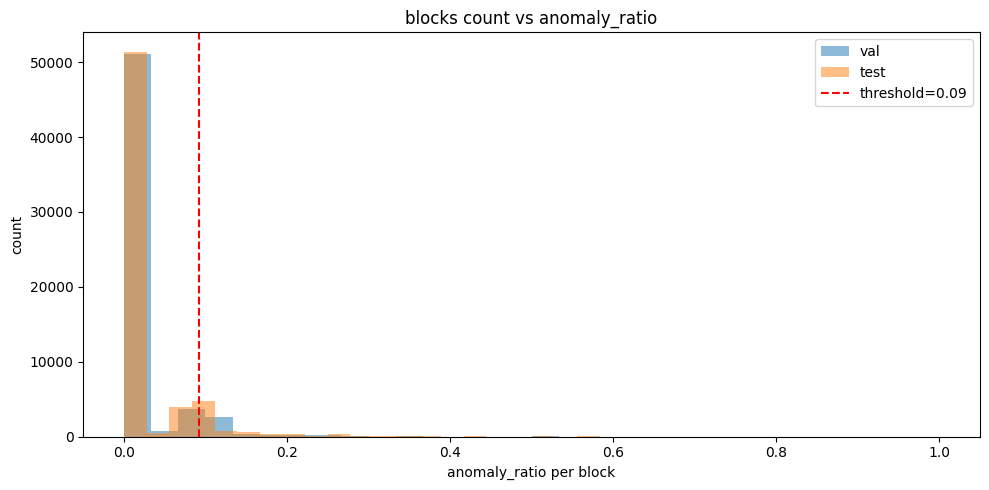

In [7]:
plt.figure(figsize=(10, 5))
plt.hist(val_ratios, bins=30, alpha=0.5, label="val")
plt.hist(test_ratios, bins=30, alpha=0.5, label="test")
plt.axvline(default_thr, color="red", linestyle="--", label=f"threshold={default_thr:.2f}")
plt.title("blocks count vs anomaly_ratio")
plt.xlabel("anomaly_ratio per block")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

- Распределения val и test близки - подбор порога по val даст хороший результатна test
- Почти все anomaly_ratio около 0 - модель хорошо предсказывает next-event для большинства блоков
- Разделимость не идеальная - есть перекрытие val и test около 0.1, это объясняет FP и FN

### Зависимость FPR от порога на валидации

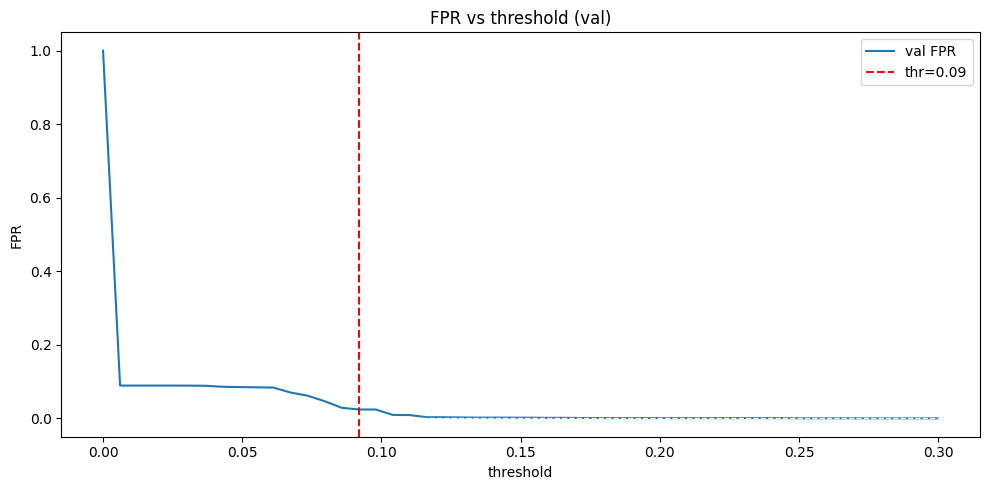

In [8]:
thresholds = np.linspace(0.0, 0.3, 50)
val_fpr = []
for t in thresholds:
    tp, fp, tn, fn = block_confusion_from_ratio_map(val_ratio_map, val_label_map, t)
    val_fpr.append(fp / (fp + tn) if (fp + tn) else 0.0)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, val_fpr, label="val FPR")
plt.axvline(default_thr, color="red", linestyle="--", label=f"thr={default_thr:.2f}")
plt.axhline(0, color="white", linestyle="--", linewidth=1)
plt.title("FPR vs threshold (val)")
plt.xlabel("threshold")
plt.ylabel("FPR")
plt.legend()
plt.tight_layout()
plt.show()

- FPR резко падает при малых порогах - даже небольшой порог (около 0.01) сильно снижает ложные срабатывания на норме
- threshold=0.09 - порог почти не допускает ложных срабатываний на норме (около 2% ложных срабатываний)

### Зависимость Precision/Recall/F1 от порога на тесте

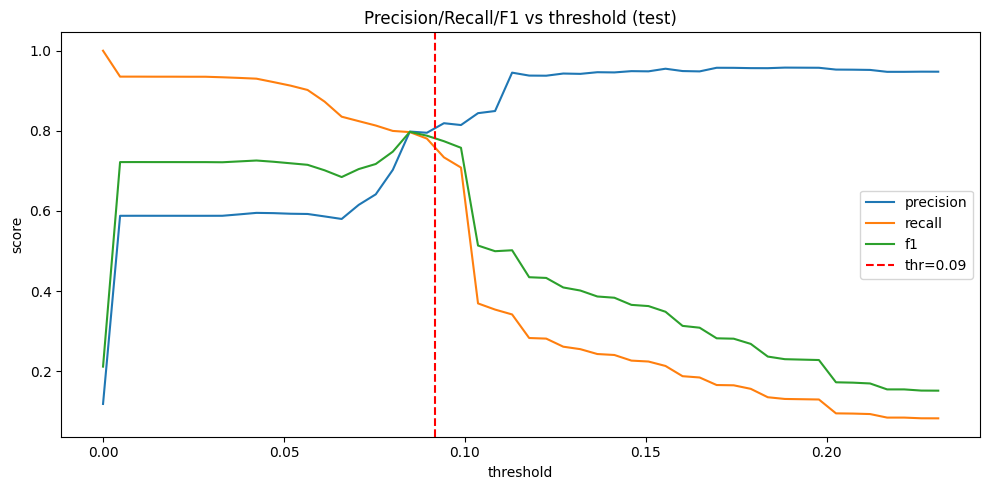

Best threshold: 0.0848
Best F1: 0.7975


In [9]:
max_thr = float(np.quantile(test_ratios, 0.99)) if test_ratios.size else 0.5
thresholds = np.linspace(0.0, max(0.2, max_thr), 50)

sweep = sweep_thresholds(test_ratio_map, test_label_map, thresholds)
thr_vals = np.array([row[0] for row in sweep])
prec_vals = np.array([row[1] for row in sweep])
rec_vals = np.array([row[2] for row in sweep])
f1_vals = np.array([row[3] for row in sweep])

plt.figure(figsize=(10, 5))
plt.plot(thr_vals, prec_vals, label="precision")
plt.plot(thr_vals, rec_vals, label="recall")
plt.plot(thr_vals, f1_vals, label="f1")
plt.axvline(default_thr, color="red", linestyle="--", label=f"thr={default_thr:.2f}")
plt.title("Precision/Recall/F1 vs threshold (test)")
plt.xlabel("threshold")
plt.ylabel("score")
plt.legend()
plt.tight_layout()
plt.show()

best_idx = int(np.argmax(f1_vals))
print("Best threshold:", round(thresholds[best_idx], 4))
print("Best F1:", round(f1_vals[best_idx], 4))

- Лучший по F1 порог на тесте threshold=0.085, при нем значение F1=0.778
- Текущий порог, подобранный на валидации (threshold=0.09) оказался близок к лучшему по тесту

### One-step LSTM: NLL scoring

Пробуем новые способы подсчета score - NLL scoring. Для target считаем `NLL = -log P(true_event)`, а затем агрегируем score по `block_id`.

In [10]:
def predict_one_step_nll(model, x, y, device, batch_size=4096):
    model.eval()
    if x.size == 0:
        return np.array([], dtype=float)
    nll_batches = []
    with torch.no_grad():
        for i in range(0, len(x), batch_size):
            xb = torch.tensor(x[i : i + batch_size], dtype=torch.long, device=device)
            yb = torch.tensor(y[i : i + batch_size], dtype=torch.long, device=device)
            logits = model(xb)
            log_probs = torch.log_softmax(logits, dim=-1)
            nll = -log_probs.gather(dim=-1, index=yb.unsqueeze(-1)).squeeze(-1)
            nll_batches.append(nll.cpu().numpy())
    return np.concatenate(nll_batches, axis=0)


def block_score_map_from_values(values, block_ids, agg="max"):
    block_to_values = {}
    for bid, value in zip(block_ids.astype(str), values):
        block_to_values.setdefault(bid, []).append(float(value))

    result = {}
    for bid, vals in block_to_values.items():
        arr = np.asarray(vals, dtype=float)
        if agg == "mean":
            result[bid] = float(arr.mean())
        elif agg == "p95":
            result[bid] = float(np.quantile(arr, 0.95))
        elif agg == "max":
            result[bid] = float(arr.max())
        else:
            raise ValueError(f"Unsupported agg={agg}")
    return result


def metrics_at_threshold(score_map, label_map, threshold):
    tp, fp, tn, fn = block_confusion_from_ratio_map(score_map, label_map, threshold)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return precision, recall, fpr, f1


def best_threshold_by_f1(score_map, label_map, num=100):
    scores = np.array(list(score_map.values()), dtype=float)
    if scores.size == 0:
        return 0.0, 0.0, 0.0, 0.0
    max_thr = float(np.quantile(scores, 0.995))
    thresholds = np.linspace(0.0, max(max_thr, float(scores.max()), 1e-9), num)
    best = (0.0, 0.0, 0.0, 0.0)
    for thr in thresholds:
        p, r, _, f1 = metrics_at_threshold(score_map, label_map, float(thr))
        if f1 > best[3]:
            best = (float(thr), p, r, f1)
    return best


def labels_scores_arrays(score_map, label_map):
    block_ids = np.array(list(score_map.keys()), dtype=str)
    scores = np.array([score_map[bid] for bid in block_ids], dtype=float)
    labels = np.array([label_map.get(bid, 0) for bid in block_ids], dtype=int)
    return labels, scores

In [11]:
val_nll = predict_one_step_nll(model, x_val, y_val, device)
test_nll = predict_one_step_nll(model, x_test, y_test, device)

score_specs = [
    ("topk_miss", val_ratio_map, test_ratio_map),
    ("nll_mean", block_score_map_from_values(val_nll, val_block_ids, "mean"), block_score_map_from_values(test_nll, test_block_ids, "mean")),
    ("nll_p95", block_score_map_from_values(val_nll, val_block_ids, "p95"), block_score_map_from_values(test_nll, test_block_ids, "p95")),
    ("nll_max", block_score_map_from_values(val_nll, val_block_ids, "max"), block_score_map_from_values(test_nll, test_block_ids, "max")),
]

ablation_rows = []
for name, val_score_map, test_score_map in score_specs:
    val_thr, val_p, val_r, val_f1 = best_threshold_by_f1(val_score_map, val_label_map)
    test_precision, test_recall, test_fpr, test_f1 = metrics_at_threshold(test_score_map, test_label_map, val_thr)
    test_thr, test_p_best, test_r_best, test_f1_best = best_threshold_by_f1(test_score_map, test_label_map)
    labels_arr, scores_arr = labels_scores_arrays(test_score_map, test_label_map)
    ap = average_precision_score(labels_arr, scores_arr)
    ablation_rows.append(
        {
            "score": name,
            "val_threshold": val_thr,
            "val_f1": val_f1,
            "test_precision": test_precision,
            "test_recall": test_recall,
            "test_f1": test_f1,
            "test_fpr": test_fpr,
            "average_precision": ap,
            "test_best_thr": test_thr,
            "test_best_f1": test_f1_best,
        }
    )

try:
    import pandas as pd
    one_step_score_df = pd.DataFrame(ablation_rows).sort_values("test_f1", ascending=False)
    display(one_step_score_df.style.format({
        "val_threshold": "{:.4f}",
        "val_f1": "{:.3f}",
        "test_precision": "{:.3f}",
        "test_recall": "{:.3f}",
        "test_f1": "{:.3f}",
        "test_fpr": "{:.4f}",
        "average_precision": "{:.3f}",
        "test_best_thr": "{:.4f}",
        "test_best_f1": "{:.3f}",
    }))
except Exception:
    for row in sorted(ablation_rows, key=lambda item: item["test_f1"], reverse=True):
        print(row)

,score,val_threshold,val_f1,test_precision,test_recall,test_f1,test_fpr,average_precision,test_best_thr,test_best_f1
3,nll_max,6.3025,0.933,0.976,0.924,0.950,0.0030,0.986,5.6022,0.960
2,nll_p95,3.9213,0.912,0.975,0.884,0.927,0.0030,0.975,3.6106,0.928
1,nll_mean,0.8501,0.901,0.969,0.872,0.918,0.0038,0.982,0.6393,0.941
0,topk_miss,0.0909,0.684,0.795,0.781,0.788,0.0269,0.787,0.0842,0.797


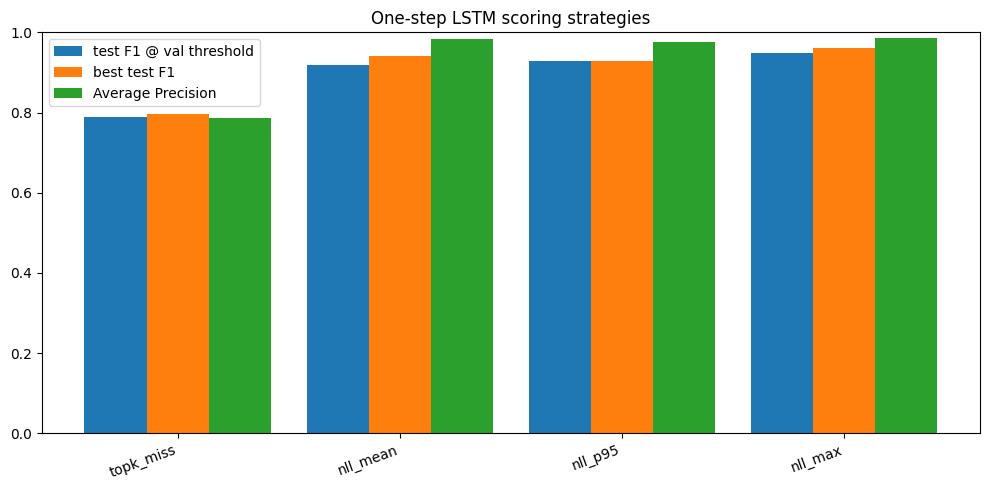

In [12]:
score_names = [row["score"] for row in ablation_rows]
test_f1_values = np.array([row["test_f1"] for row in ablation_rows])
test_best_f1_values = np.array([row["test_best_f1"] for row in ablation_rows])
ap_values = np.array([row["average_precision"] for row in ablation_rows])

x = np.arange(len(score_names))
width = 0.28

plt.figure(figsize=(10, 5))
plt.bar(x - width, test_f1_values, width, label="test F1 @ val threshold")
plt.bar(x, test_best_f1_values, width, label="best test F1")
plt.bar(x + width, ap_values, width, label="Average Precision")
plt.xticks(x, score_names, rotation=20, ha="right")
plt.ylim(0, max(1.0, float(max(test_best_f1_values.max(), ap_values.max()))))
plt.title("One-step LSTM scoring strategies")
plt.legend()
plt.tight_layout()
plt.show()